# Product analytics: анализ e-commerce маркетплейса Olist

**Цель проекта:** проанализировать ключевые метрики e-commerce маркетплейса: GMV, сумму оплаты клиента, средний чек, повторные покупки, retention, доставку, отзывы и клиентские сегменты.

**Датасет:**

https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce/data

**Стек:** Python, pandas, SQLite, SQL, matplotlib, seaborn.

## План

1. Загрузка и первичный анализ таблиц.
2. Создание SQLite-базы и выполнение SQL-запросов.
3. Расчёт бизнес-метрик: GMV, сумма доставки, total customer paid, AOV.
4. Анализ статусов заказов и повторных покупок.
5. Анализ товарных категорий.
6. Анализ доставки и связи задержек с отзывами.
7. Когортный retention.
8. RFM-сегментация клиентов.
9. Продуктовые выводы и рекомендации.



## 0. Подготовка данных

1. Скачайте датасет **Brazilian E-Commerce Public Dataset by Olist** с Kaggle.
2. Загрузите архив в Colab и назовите его `archive.zip`, либо положите CSV-файлы в папку `/content/olist`.

Ожидаемые CSV-файлы:

```text
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_customers_dataset.csv
olist_products_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv
```

In [185]:
import os
import sqlite3
import warnings
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [186]:
# Папка с данными
DATA_DIR = "/content/olist"
os.makedirs(DATA_DIR, exist_ok=True)

# Если вы загрузили archive.zip в Colab, распакуем его.
archive_path = "/content/archive.zip"
if os.path.exists(archive_path):
    with ZipFile(archive_path, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

print("Files in DATA_DIR:")
for file in sorted(os.listdir(DATA_DIR)):
    print("-", file)

Files in DATA_DIR:
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_items_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_orders_dataset.csv
- olist_products_dataset.csv
- olist_sellers_dataset.csv
- product_category_name_translation.csv


In [187]:
required_files = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "products": "olist_products_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

missing = [filename for filename in required_files.values() if not os.path.exists(os.path.join(DATA_DIR, filename))]
if missing:
    print("Не найдены файлы:")
    for file in missing:
        print("-", file)
    print("Загрузите CSV-файлы в DATA_DIR или загрузите archive.zip в /content/archive.zip")
else:
    print("Все нужные файлы найдены.")

Все нужные файлы найдены.


## 1. Загрузка таблиц

In [141]:
orders = pd.read_csv(os.path.join(DATA_DIR, required_files["orders"]))
order_items = pd.read_csv(os.path.join(DATA_DIR, required_files["order_items"]))
customers = pd.read_csv(os.path.join(DATA_DIR, required_files["customers"]))
products = pd.read_csv(os.path.join(DATA_DIR, required_files["products"]))
payments = pd.read_csv(os.path.join(DATA_DIR, required_files["payments"]))
reviews = pd.read_csv(os.path.join(DATA_DIR, required_files["reviews"]))
sellers = pd.read_csv(os.path.join(DATA_DIR, required_files["sellers"]))
category_translation = pd.read_csv(os.path.join(DATA_DIR, required_files["category_translation"]))

tables = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "payments": payments,
    "reviews": reviews,
    "sellers": sellers,
    "category_translation": category_translation,
}

for name, table in tables.items():
    print(f"{name:22s}: {table.shape}")

orders                : (99441, 8)
order_items           : (112650, 7)
customers             : (99441, 5)
products              : (32951, 9)
payments              : (103886, 5)
reviews               : (99224, 7)
sellers               : (3095, 4)
category_translation  : (71, 2)


In [142]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [143]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


## 2. Первичный анализ данных

Посмотрим типы данных, пропуски и статусы заказов.

In [144]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [145]:
orders.isna().sum().sort_values(ascending=False)

,0
order_delivered_customer_date,2965
order_delivered_carrier_date,1783
order_approved_at,160
order_id,0
order_purchase_timestamp,0
order_status,0
customer_id,0
order_estimated_delivery_date,0


In [146]:
orders["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


Для бизнес-метрик обычно будем использовать заказы со статусом `delivered`, потому что они завершены и дошли до клиента.

In [147]:
completed_orders = orders[orders["order_status"] == "delivered"].copy()
print("Delivered orders:", completed_orders.shape[0])
print("All orders:", orders.shape[0])
print("Delivered share:", round(completed_orders.shape[0] / orders.shape[0], 4))

Delivered orders: 96478
All orders: 99441
Delivered share: 0.9702


### Промежуточный вывод: качество и состав данных

В таблице заказов 99 441 запись, из них 96 478 заказов имеют статус `delivered`, то есть около 97% всех заказов завершены доставкой. Для расчёта выручки, среднего чека, доставки и отзывов корректно использовать именно доставленные заказы: они отражают завершённый пользовательский сценарий.

Пропуски в датах доставки в основном связаны с заказами, которые не были доставлены или не дошли до финальной стадии.

## 3. Подготовка дат и дополнительных признаков

In [148]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders["order_date"] = orders["order_purchase_timestamp"].dt.date

orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["estimated_delivery_days"] = (
    orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

orders[["order_id", "order_status", "order_month", "delivery_days", "delivery_delay_days"]].head()

,order_id,order_status,order_month,delivery_days,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10,8.0,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07,13.0,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08,9.0,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11,13.0,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02,2.0,-10.0


## 4. Создание SQLite-базы

Создадим SQLite-базу, чтобы считать метрики через SQL.

In [149]:
DB_PATH = "olist.db"
conn = sqlite3.connect(DB_PATH)

orders.to_sql("orders", conn, index=False, if_exists="replace")
order_items.to_sql("order_items", conn, index=False, if_exists="replace")
customers.to_sql("customers", conn, index=False, if_exists="replace")
products.to_sql("products", conn, index=False, if_exists="replace")
payments.to_sql("payments", conn, index=False, if_exists="replace")
reviews.to_sql("reviews", conn, index=False, if_exists="replace")
sellers.to_sql("sellers", conn, index=False, if_exists="replace")
category_translation.to_sql("category_translation", conn, index=False, if_exists="replace")

pd.read_sql_query("SELECT name FROM sqlite_master WHERE type = 'table';", conn)

,name
0,orders
1,order_items
2,customers
3,products
4,payments
5,reviews
6,sellers
7,category_translation


In [150]:
def run_sql(query):
    return pd.read_sql_query(query, conn)

## 5. Бизнес-метрики: GMV, Total customer paid, AOV и оценочная revenue

В датасете Olist есть стоимость товара (`price`) и стоимость доставки (`freight_value`), но нет информации о комиссии маркетплейса. Поэтому фактическую выручку платформы Olist посчитать напрямую нельзя.

В проекте используются следующие определения:

- **GMV** — сумма стоимости товаров в доставленных заказах: `SUM(price)`.
- **Freight value** — сумма стоимости доставки: `SUM(freight_value)`.
- **Total customer paid** — полная сумма, которую заплатили покупатели: `SUM(price + freight_value)`.
- **AOV without freight** — средний чек без доставки.
- **AOV with freight** — средний чек с доставкой.
- **Estimated platform revenue** — сценарная оценка дохода платформы при заданной комиссии от GMV.



In [151]:
query = """
SELECT
    ROUND(SUM(oi.price), 2) AS gmv,
    ROUND(SUM(oi.freight_value), 2) AS freight_value,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_customer_paid,
    COUNT(DISTINCT o.order_id) AS delivered_orders,
    COUNT(DISTINCT c.customer_unique_id) AS unique_customers
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';
"""

business_metrics = run_sql(query)
business_metrics


,gmv,freight_value,total_customer_paid,delivered_orders,unique_customers
0,13221498.11,2198275.64,15419773.75,96478,93358


### Сценарная оценка выручки платформы
`Estimated platform revenue` — это **не фактическая выручка**, а оценка при выбранной комиссии от GMV. В проекте используются несколько сценариев: 10%, 15% и 20%. Такой подход помогает оценить возможный диапазон дохода платформы, но не подменяет реальные финансовые данные компании.


In [152]:
gmv = business_metrics.loc[0, "gmv"]

commission_rates = [0.10, 0.15, 0.20]

commission_scenarios = pd.DataFrame({
    "commission_rate": commission_rates,
    "estimated_platform_revenue": [gmv * rate for rate in commission_rates]
})

commission_scenarios["commission_rate"] = commission_scenarios["commission_rate"].map(lambda x: f"{x:.0%}")
commission_scenarios["estimated_platform_revenue"] = commission_scenarios["estimated_platform_revenue"].round(2)

commission_scenarios


,commission_rate,estimated_platform_revenue
0,10%,1322149.81
1,15%,1983224.72
2,20%,2644299.62


In [153]:
query = """
WITH order_values AS (
    SELECT
        o.order_id,
        SUM(oi.price) AS order_items_value,
        SUM(oi.freight_value) AS order_freight_value,
        SUM(oi.price + oi.freight_value) AS order_total_value
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.order_id
)

SELECT
    ROUND(AVG(order_items_value), 2) AS avg_order_value_without_freight,
    ROUND(AVG(order_total_value), 2) AS avg_order_value_with_freight,
    ROUND(MIN(order_total_value), 2) AS min_order_value_with_freight,
    ROUND(MAX(order_total_value), 2) AS max_order_value_with_freight
FROM order_values;
"""

aov = run_sql(query)
aov


,avg_order_value_without_freight,avg_order_value_with_freight,min_order_value_with_freight,max_order_value_with_freight
0,137.04,159.83,9.59,13664.08


## 6. Динамика GMV и заказов по месяцам

In [154]:
query = """
SELECT
    substr(o.order_purchase_timestamp, 1, 7) AS month,
    ROUND(SUM(oi.price), 2) AS gmv,
    ROUND(SUM(oi.freight_value), 2) AS freight_value,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_customer_paid,
    COUNT(DISTINCT o.order_id) AS orders,
    COUNT(DISTINCT c.customer_unique_id) AS customers
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY month
ORDER BY month;
"""

monthly_metrics = run_sql(query)
monthly_metrics.head()


,month,gmv,freight_value,total_customer_paid,orders,customers
0,2016-09,134.97,8.49,143.46,1,1
1,2016-10,40325.11,6165.55,46490.66,265,262
2,2016-12,10.90,8.72,19.62,1,1
3,2017-01,111798.36,15684.01,127482.37,750,718
4,2017-02,234223.40,37015.92,271239.32,1653,1630


### Сценарная оценка revenue по месяцам



In [155]:
monthly_metrics_with_estimated_revenue = monthly_metrics.copy()

for rate in [0.10, 0.15, 0.20]:
    monthly_metrics_with_estimated_revenue[f"estimated_revenue_{int(rate * 100)}pct"] = (
        monthly_metrics_with_estimated_revenue["gmv"] * rate
    ).round(2)

monthly_metrics_with_estimated_revenue.head()


,month,gmv,freight_value,total_customer_paid,orders,customers,estimated_revenue_10pct,estimated_revenue_15pct,estimated_revenue_20pct
0,2016-09,134.97,8.49,143.46,1,1,13.50,20.25,26.99
1,2016-10,40325.11,6165.55,46490.66,265,262,4032.51,6048.77,8065.02
2,2016-12,10.90,8.72,19.62,1,1,1.09,1.64,2.18
3,2017-01,111798.36,15684.01,127482.37,750,718,11179.84,16769.75,22359.67
4,2017-02,234223.40,37015.92,271239.32,1653,1630,23422.34,35133.51,46844.68


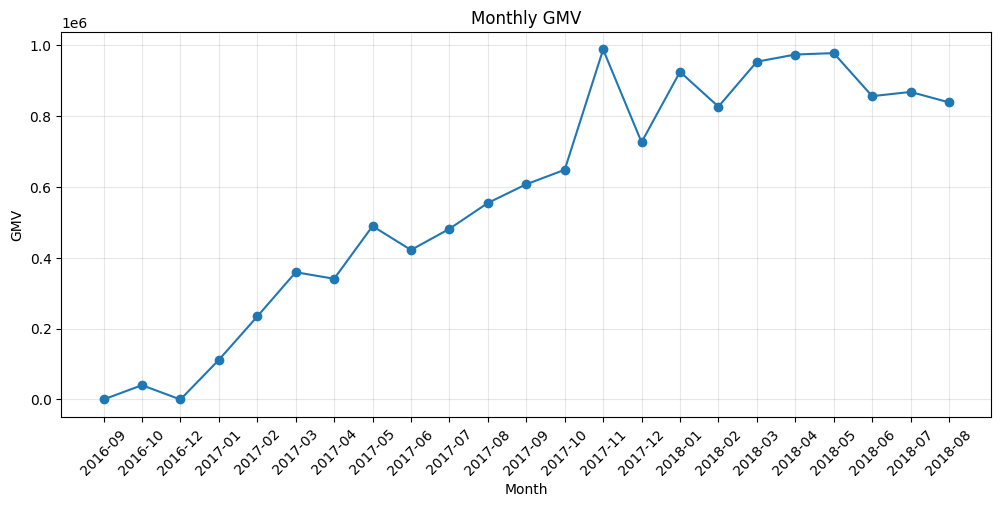

In [156]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_metrics["month"], monthly_metrics["gmv"], marker="o")
plt.title("Monthly GMV")
plt.xlabel("Month")
plt.ylabel("GMV")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


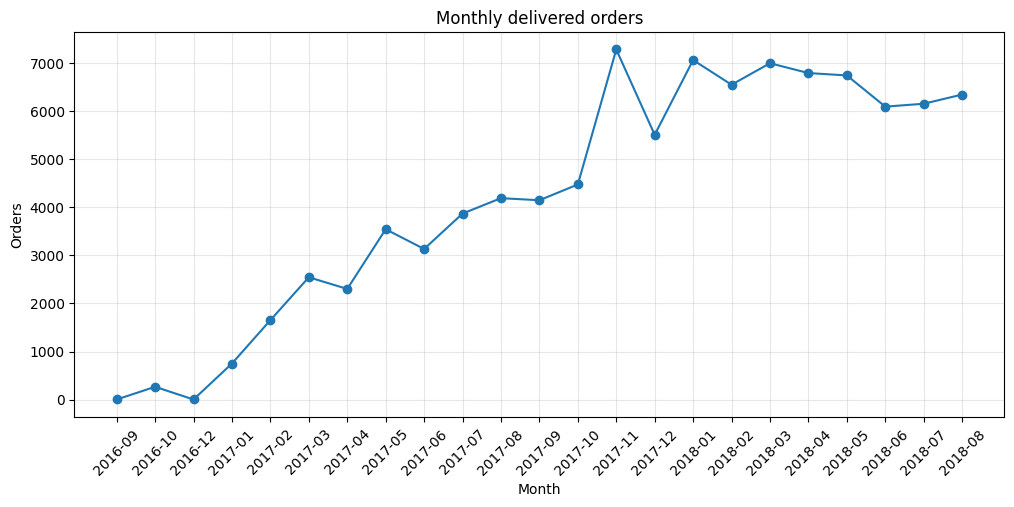

In [157]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_metrics["month"], monthly_metrics["orders"], marker="o")
plt.title("Monthly delivered orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

### Промежуточный вывод: динамика по месяцам

Динамика заказов и GMV показывает рост маркетплейса в основной части периода наблюдений. При интерпретации важно аккуратно относиться к первым и последним месяцам: они могут быть неполными, поэтому резкие значения на краях временного ряда не стоит трактовать как полноценный тренд.



## 7. Статусы заказов и отмены

In [158]:
query = """
SELECT
    order_status,
    COUNT(*) AS orders,
    ROUND(COUNT(*) * 1.0 / (SELECT COUNT(*) FROM orders), 4) AS share
FROM orders
GROUP BY order_status
ORDER BY orders DESC;
"""

status_distribution = run_sql(query)
status_distribution

,order_status,orders,share
0,delivered,96478,0.9702
1,shipped,1107,0.0111
2,canceled,625,0.0063
3,unavailable,609,0.0061
4,invoiced,314,0.0032
5,processing,301,0.0030
6,created,5,0.0001
7,approved,2,0.0000


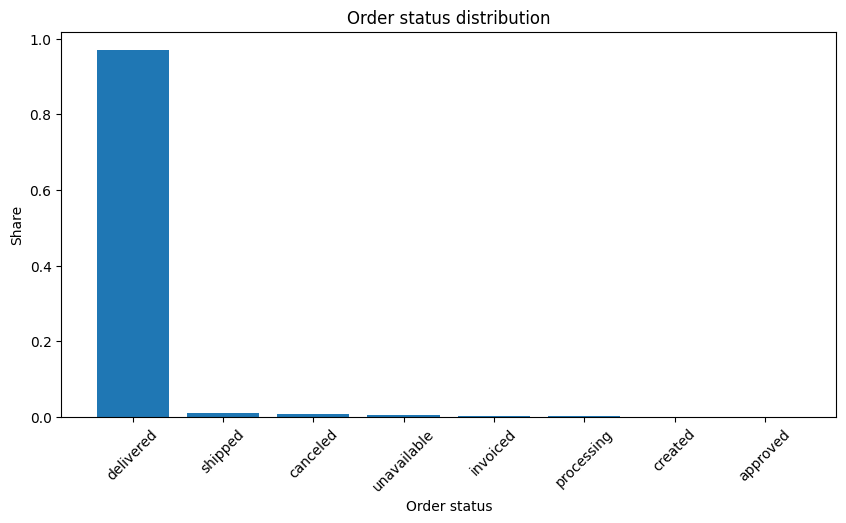

In [159]:
plt.figure(figsize=(10, 5))
plt.bar(status_distribution["order_status"], status_distribution["share"])
plt.title("Order status distribution")
plt.xlabel("Order status")
plt.ylabel("Share")
plt.xticks(rotation=45)
plt.show()

### Промежуточный вывод: статусы заказов

Основная часть заказов доставлена клиентам. Доля отменённых и недоступных заказов относительно небольшая, но эти статусы всё равно важны как guardrail-метрики: рост отмен или unavailable-заказов может ухудшать пользовательский опыт и снижать доверие к маркетплейсу.


## 8. Повторные покупки


In [160]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS delivered_orders
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    COUNT(CASE WHEN delivered_orders >= 2 THEN customer_unique_id END) AS repeat_customers,
    COUNT(customer_unique_id) AS total_customers,
    ROUND(
        COUNT(CASE WHEN delivered_orders >= 2 THEN customer_unique_id END) * 1.0 / COUNT(customer_unique_id),
        4
    ) AS repeat_purchase_rate
FROM customer_orders;
"""

repeat_purchase = run_sql(query)
repeat_purchase

,repeat_customers,total_customers,repeat_purchase_rate
0,2801,93358,0.03


In [161]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS delivered_orders
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    delivered_orders,
    COUNT(*) AS customers
FROM customer_orders
GROUP BY delivered_orders
ORDER BY delivered_orders;
"""

customer_order_distribution = run_sql(query)
customer_order_distribution.head(10)

,delivered_orders,customers
0,1,90557
1,2,2573
2,3,181
3,4,28
4,5,9
5,6,5
6,7,3
7,9,1
8,15,1


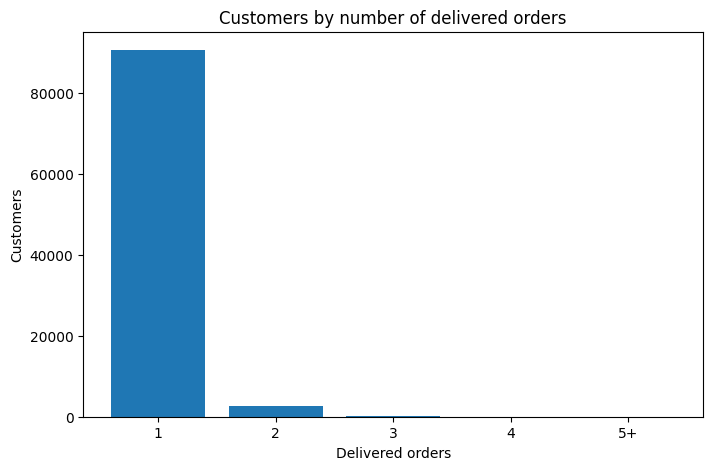

In [162]:
dist_plot = customer_order_distribution.copy()
dist_plot["orders_group"] = np.where(dist_plot["delivered_orders"] >= 5, "5+", dist_plot["delivered_orders"].astype(str))
dist_plot = dist_plot.groupby("orders_group", as_index=False)["customers"].sum()

plt.figure(figsize=(8, 5))
plt.bar(dist_plot["orders_group"], dist_plot["customers"])
plt.title("Customers by number of delivered orders")
plt.xlabel("Delivered orders")
plt.ylabel("Customers")
plt.show()

### Промежуточный вывод: повторные покупки

Repeat purchase rate составляет около 3%. Это один из главных продуктовых инсайтов проекта: большинство клиентов совершает только один доставленный заказ. Для маркетплейса это означает потенциальную проблему удержания и возможность роста через механики повторной покупки.


## 9. Топ товарных категорий по GMV

In [163]:
query = """
SELECT
    COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS category,
    ROUND(SUM(oi.price), 2) AS gmv,
    COUNT(DISTINCT oi.order_id) AS orders,
    COUNT(*) AS items_sold
FROM order_items oi
JOIN orders o ON oi.order_id = o.order_id
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation t
    ON p.product_category_name = t.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY gmv DESC
LIMIT 15;
"""

top_categories = run_sql(query)
top_categories


,category,gmv,orders,items_sold
0,health_beauty,1233131.72,8647,9465
1,watches_gifts,1166176.98,5495,5859
2,bed_bath_table,1023434.76,9272,10953
3,sports_leisure,954852.55,7530,8431
4,computers_accessories,888724.61,6530,7644
5,furniture_decor,711927.69,6307,8160
6,housewares,615628.69,5743,6795
7,cool_stuff,610204.10,3559,3718
8,auto,578966.65,3810,4140
9,toys,471286.48,3804,4030


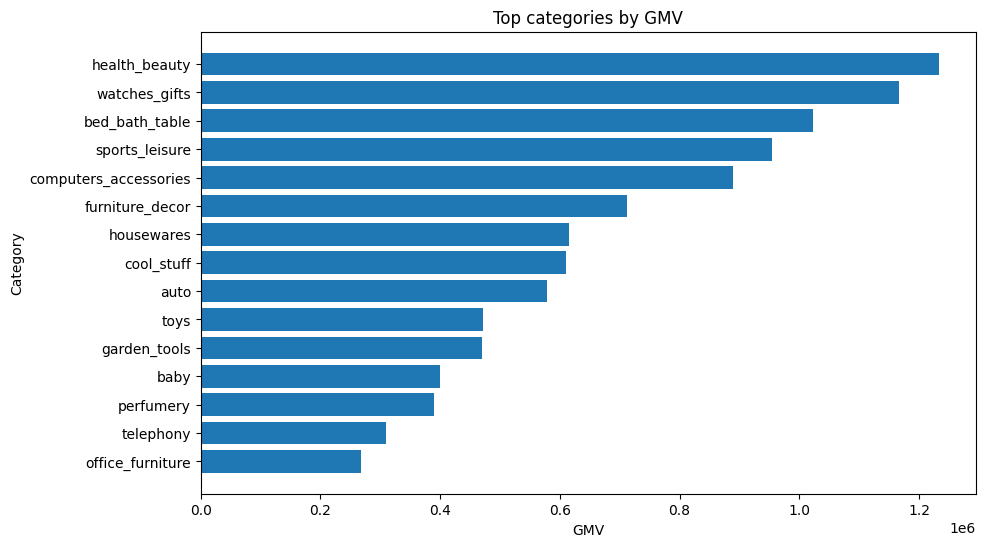

In [164]:
plt.figure(figsize=(10, 6))
plt.barh(top_categories["category"][::-1], top_categories["gmv"][::-1])
plt.title("Top categories by GMV")
plt.xlabel("GMV")
plt.ylabel("Category")
plt.show()


### Промежуточный вывод: товарные категории

GMV концентрируется в нескольких категориях: среди лидеров `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure` и `computers_accessories`. Эти категории можно рассматривать как ключевые для фокуса маркетинга, рекомендаций и контроля качества доставки, потому что они дают большой вклад в общий товарный оборот.


## 10. Анализ доставки

Проверим средний срок доставки и долю заказов с задержкой относительно обещанной даты.

In [165]:
query = """
SELECT
    ROUND(AVG(delivery_days), 2) AS avg_delivery_days,
    ROUND(AVG(estimated_delivery_days), 2) AS avg_estimated_delivery_days,
    ROUND(AVG(delivery_delay_days), 2) AS avg_delay_days,
    ROUND(
        COUNT(CASE WHEN delivery_delay_days > 0 THEN order_id END) * 1.0 / COUNT(order_id),
        4
    ) AS late_delivery_rate
FROM orders
WHERE order_status = 'delivered'
  AND delivery_days IS NOT NULL;
"""

delivery_metrics = run_sql(query)
delivery_metrics

,avg_delivery_days,avg_estimated_delivery_days,avg_delay_days,late_delivery_rate
0,12.09,23.37,-11.88,0.0677


In [166]:
query = """
SELECT
    c.customer_state,
    COUNT(DISTINCT o.order_id) AS orders,
    ROUND(AVG(o.delivery_days), 2) AS avg_delivery_days,
    ROUND(AVG(o.delivery_delay_days), 2) AS avg_delay_days,
    ROUND(COUNT(CASE WHEN o.delivery_delay_days > 0 THEN o.order_id END) * 1.0 / COUNT(o.order_id), 4) AS late_delivery_rate
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.delivery_days IS NOT NULL
GROUP BY c.customer_state
HAVING orders >= 100
ORDER BY late_delivery_rate DESC
LIMIT 15;
"""

late_by_state = run_sql(query)
late_by_state

,customer_state,orders,avg_delivery_days,avg_delay_days,late_delivery_rate
0,AL,397,24.04,-8.71,0.2141
1,MA,717,21.12,-9.57,0.1743
2,SE,335,21.03,-10.02,0.1522
3,PI,476,18.99,-11.31,0.1387
4,CE,1279,20.82,-10.80,0.1376
5,BA,3256,18.87,-10.79,0.1216
6,RJ,12350,14.85,-11.76,0.1211
7,PA,946,23.32,-14.07,0.1121
8,ES,1995,15.33,-10.50,0.1073
9,PB,517,19.95,-13.26,0.1044


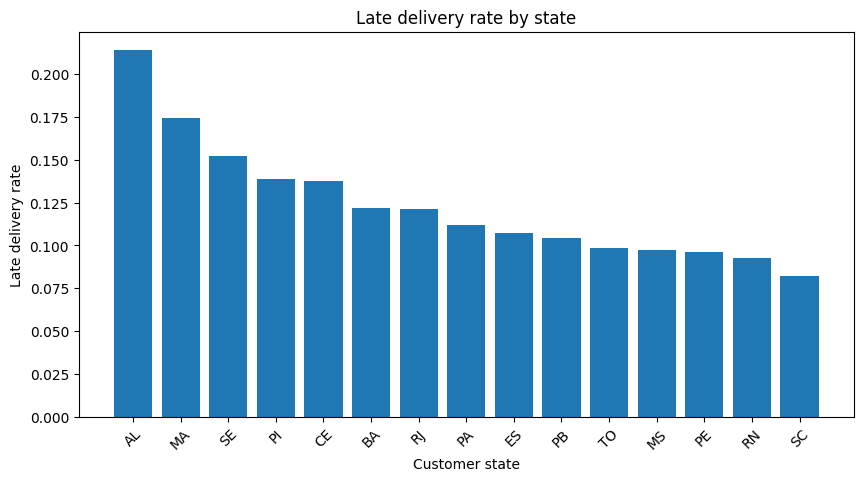

In [167]:
plt.figure(figsize=(10, 5))
plt.bar(late_by_state["customer_state"], late_by_state["late_delivery_rate"])
plt.title("Late delivery rate by state")
plt.xlabel("Customer state")
plt.ylabel("Late delivery rate")
plt.xticks(rotation=45)
plt.show()

### Промежуточный вывод: доставка

Средний срок доставки составляет около 12 дней, при этом средняя доставка происходит раньше обещанной даты. Однако late delivery rate около 6.8%, а по отдельным штатам доля задержек существенно выше. Это значит, что среднее значение скрывает региональные проблемы, поэтому доставку нужно анализировать по географии и продавцам.


## 11. Связь задержек доставки с отзывами


In [168]:
query = """
SELECT
    CASE
        WHEN o.delivery_delay_days <= 0 THEN 'on_time_or_early'
        WHEN o.delivery_delay_days BETWEEN 1 AND 3 THEN 'delay_1_3_days'
        WHEN o.delivery_delay_days BETWEEN 4 AND 7 THEN 'delay_4_7_days'
        ELSE 'delay_8_plus_days'
    END AS delivery_delay_group,
    COUNT(DISTINCT o.order_id) AS orders,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM orders o
JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.delivery_delay_days IS NOT NULL
GROUP BY delivery_delay_group
ORDER BY avg_review_score DESC;
"""

delay_reviews = run_sql(query)
delay_reviews

,delivery_delay_group,orders,avg_review_score
0,on_time_or_early,89443,4.29
1,delay_1_3_days,1852,3.29
2,delay_4_7_days,1748,2.10
3,delay_8_plus_days,2781,1.70


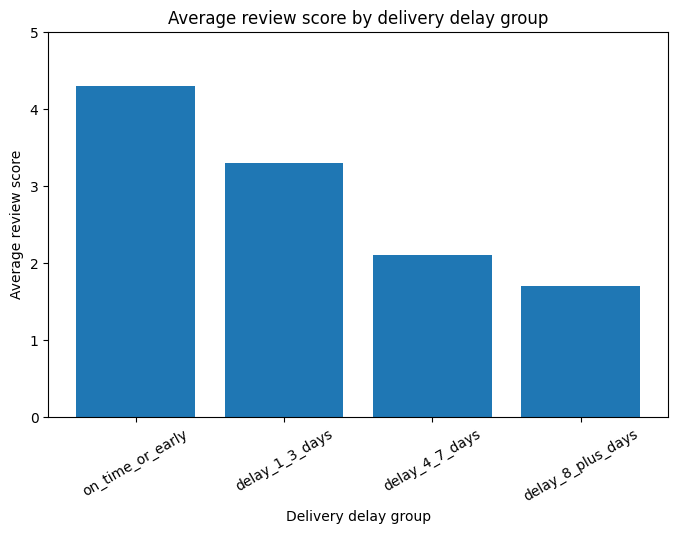

In [169]:
plt.figure(figsize=(8, 5))
plt.bar(delay_reviews["delivery_delay_group"], delay_reviews["avg_review_score"])
plt.title("Average review score by delivery delay group")
plt.xlabel("Delivery delay group")
plt.ylabel("Average review score")
plt.xticks(rotation=30)
plt.ylim(0, 5)
plt.show()

### Промежуточный вывод: доставка и отзывы

Задержка доставки заметно связана с ухудшением оценок: заказы, доставленные вовремя или раньше срока, имеют среднюю оценку около 4.29, а при задержке больше 8 дней средняя оценка падает примерно до 1.70. Это сильный продуктовый сигнал: доставка напрямую влияет на пользовательский опыт и должна быть одной из ключевых guardrail-метрик.


## 12. Когортное удержание


In [170]:
cursor = conn.cursor()

# Создаём временную таблицу с доставленными заказами
cursor.execute("DROP TABLE IF EXISTS delivered_orders;")

cursor.execute("""
CREATE TEMP TABLE delivered_orders AS
SELECT
    o.order_id,
    c.customer_unique_id,
    substr(o.order_purchase_timestamp, 1, 7) AS order_month
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp IS NOT NULL;
""")

cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_delivered_orders_customer_month
ON delivered_orders(customer_unique_id, order_month);
""")

conn.commit()

In [171]:
# Для каждого клиента определяем месяц первой покупки
cursor.execute("DROP TABLE IF EXISTS first_orders;")

cursor.execute("""
CREATE TEMP TABLE first_orders AS
SELECT
    customer_unique_id,
    MIN(order_month) AS cohort_month
FROM delivered_orders
GROUP BY customer_unique_id;
""")

cursor.execute("""
CREATE INDEX IF NOT EXISTS idx_first_orders_customer
ON first_orders(customer_unique_id);
""")

conn.commit()

In [172]:
# Считаем количество активных клиентов по когортам и месяцам после первой покупки
query = """
SELECT
    f.cohort_month,
    d.order_month,
    (
        (CAST(substr(d.order_month, 1, 4) AS INTEGER) - CAST(substr(f.cohort_month, 1, 4) AS INTEGER)) * 12
        +
        (CAST(substr(d.order_month, 6, 2) AS INTEGER) - CAST(substr(f.cohort_month, 6, 2) AS INTEGER))
    ) AS period_number,
    COUNT(DISTINCT d.customer_unique_id) AS customers
FROM delivered_orders d
JOIN first_orders f
    ON d.customer_unique_id = f.customer_unique_id
GROUP BY
    f.cohort_month,
    d.order_month,
    period_number
HAVING period_number BETWEEN 0 AND 6
ORDER BY
    f.cohort_month,
    period_number;
"""

cohorts = pd.read_sql_query(query, conn)

cohorts.head()

,cohort_month,order_month,period_number,customers
0,2016-09,2016-09,0,1
1,2016-10,2016-10,0,262
2,2016-10,2017-04,6,1
3,2016-12,2016-12,0,1
4,2016-12,2017-01,1,1


In [173]:
# Строим cohort pivot: строки — когорты, колонки — месяцы после первой покупки

cohort_pivot = cohorts.pivot_table(
    index="cohort_month",
    columns="period_number",
    values="customers"
)

# Размер каждой когорты — число клиентов в месяц первой покупки
cohort_sizes = cohort_pivot[0].astype(int)

# Retention = активные клиенты в месяц N / размер когорты
retention = cohort_pivot.divide(cohort_sizes, axis=0)

retention.head()

period_number,0,1,2,3,4,5,6
cohort_month,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,0.002789,0.001395,0.004184,0.001395,0.004184
2017-02,1.0,0.001843,0.003071,0.001229,0.004300,0.001229,0.002457


In [174]:
# Проверяем размеры когорт

cohort_size_table = pd.DataFrame({
    "cohort_size": cohort_sizes
})

cohort_size_table.head(15)


,cohort_size
cohort_month,
2016-09,1
2016-10,262
2016-12,1
2017-01,717
2017-02,1628
2017-03,2503
2017-04,2256
2017-05,3451
2017-06,3037


In [175]:
# Фильтруем маленькие когорты

# Маленькие когорты могут давать нестабильные значения.
# Например, если в когорте 1 клиент и он вернулся, retention будет 100%.
# Поэтому для визуализации оставим только когорты от 100 клиентов.

min_cohort_size = 100

valid_cohorts = cohort_sizes[cohort_sizes >= min_cohort_size].index

retention_filtered = retention.loc[valid_cohorts].copy()

# Убираем 0-й месяц, потому что он всегда равен 100%
retention_filtered = retention_filtered.drop(columns=[0], errors="ignore")

retention_filtered.head()

period_number,1,2,3,4,5,6
cohort_month,,,,,,
2016-10,NaN,NaN,NaN,NaN,NaN,0.003817
2017-01,0.002789,0.002789,0.001395,0.004184,0.001395,0.004184
2017-02,0.001843,0.003071,0.001229,0.004300,0.001229,0.002457
2017-03,0.004395,0.003596,0.003995,0.003596,0.001598,0.001598
2017-04,0.006206,0.002216,0.001773,0.002660,0.002660,0.003546


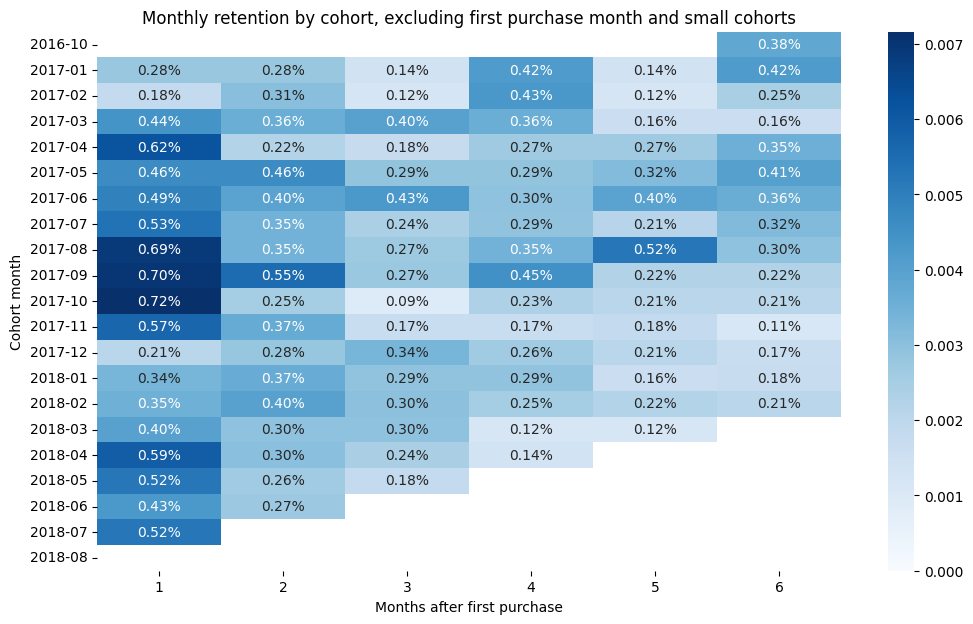

In [176]:
# Строим heatmap retention

plt.figure(figsize=(12, 7))

sns.heatmap(
    retention_filtered,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    vmin=0,
    vmax=retention_filtered.max().max()
)

plt.title("Monthly retention by cohort, excluding first purchase month and small cohorts")
plt.xlabel("Months after first purchase")
plt.ylabel("Cohort month")
plt.show()

In [177]:
# Считаем средний retention по месяцам после первой покупки

avg_retention_by_period = retention_filtered.mean().reset_index()

avg_retention_by_period.columns = [
    "months_after_first_purchase",
    "avg_retention"
]

avg_retention_by_period

,months_after_first_purchase,avg_retention
0,1,0.004757
1,2,0.003370
2,3,0.002506
3,4,0.002883
4,5,0.002305
5,6,0.002694


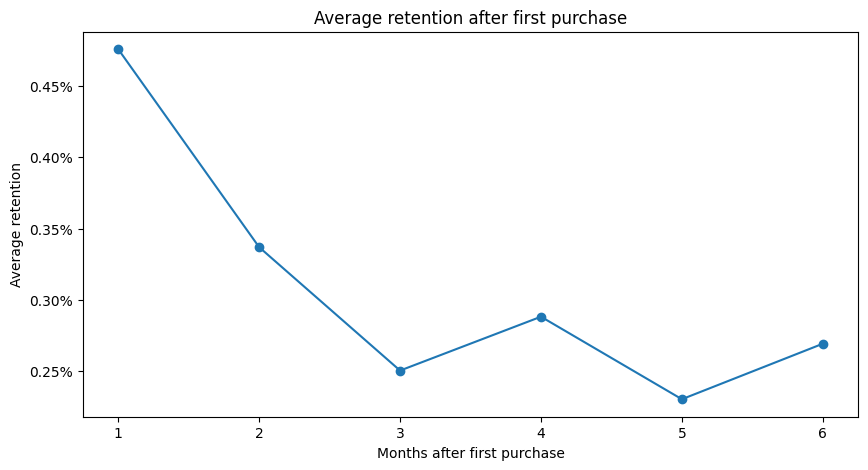

In [178]:
# График среднего retention по месяцам после первой покупки

plt.figure(figsize=(10, 5))

plt.plot(
    avg_retention_by_period["months_after_first_purchase"],
    avg_retention_by_period["avg_retention"],
    marker="o"
)

plt.title("Average retention after first purchase")
plt.xlabel("Months after first purchase")
plt.ylabel("Average retention")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2%}"))

plt.show()

### Промежуточный вывод: когортный retention
  По матрице видно, что повторные покупки после первого месяца находятся на очень низком уровне — обычно меньше 1%. Это означает, что Olist в рассматриваемом датасете выглядит как маркетплейс с большой долей разовых покупателей. Потенциальная зона роста — механики удержания: персональные рекомендации, коммуникации после покупки, скидки на повторный заказ и улучшение опыта доставки.


## 13. RFM-сегментация клиентов


In [179]:
snapshot_date = orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_query = """
WITH order_revenue AS (
    SELECT
        o.order_id,
        c.customer_unique_id,
        o.order_purchase_timestamp,
        SUM(oi.price) AS revenue
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY o.order_id, c.customer_unique_id, o.order_purchase_timestamp
)

SELECT
    customer_unique_id,
    MAX(order_purchase_timestamp) AS last_order_date,
    COUNT(DISTINCT order_id) AS frequency,
    SUM(revenue) AS monetary
FROM order_revenue
GROUP BY customer_unique_id;
"""

rfm = run_sql(rfm_query)
rfm["last_order_date"] = pd.to_datetime(rfm["last_order_date"])
rfm["recency"] = (snapshot_date - rfm["last_order_date"]).dt.days

rfm.head()

,customer_unique_id,last_order_date,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90,161
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90,164
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00,586
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99,370
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00,337


### Методологическая правка RFM

В датасете Olist повторные покупки встречаются редко: repeat purchase rate около 3%. Поэтому нельзя честно разбивать `frequency` на квартильные группы через `qcut` с `rank(method="first")`: большинство клиентов имеют `frequency = 1`, и ранжирование искусственно создаёт различия там, где фактически их почти нет.

Вместо этого используем более честный подход:
- `recency` и `monetary` делим на квартильные оценки;
- `frequency` учитываем как факт повторной покупки: `one_time` или `repeat`;
- сегменты строим на основе недавности, ценности и повторности покупок.


In [180]:
# Более корректная RFM-сегментация для датасета с низкой долей повторных покупок

rfm["r_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
)

rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

rfm["frequency_segment"] = np.where(
    rfm["frequency"] >= 2,
    "repeat",
    "one_time"
)

rfm.head()


,customer_unique_id,last_order_date,frequency,monetary,recency,r_score,m_score,frequency_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90,161,4,3,one_time
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90,164,4,1,one_time
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00,586,1,2,one_time
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99,370,2,1,one_time
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00,337,2,4,one_time


In [181]:
def segment_customer(row):
    r = int(row["r_score"])
    m = int(row["m_score"])
    is_repeat = row["frequency"] >= 2

    if is_repeat and r >= 3 and m >= 3:
        return "best_customers"
    elif is_repeat and r <= 2:
        return "repeat_at_risk"
    elif (not is_repeat) and r >= 3 and m >= 3:
        return "new_high_value"
    elif (not is_repeat) and r >= 3:
        return "new_one_time"
    elif (not is_repeat) and r <= 2 and m >= 3:
        return "high_value_inactive"
    elif (not is_repeat) and r <= 2:
        return "lost_one_time"
    else:
        return "regular_customers"


rfm["segment"] = rfm.apply(segment_customer, axis=1)

segment_counts = (
    rfm["segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["segment", "customers"]
segment_counts


,segment,customers
0,lost_one_time,23379
1,new_one_time,22842
2,new_high_value,22294
3,high_value_inactive,22042
4,best_customers,1310
5,repeat_at_risk,1258
6,regular_customers,233


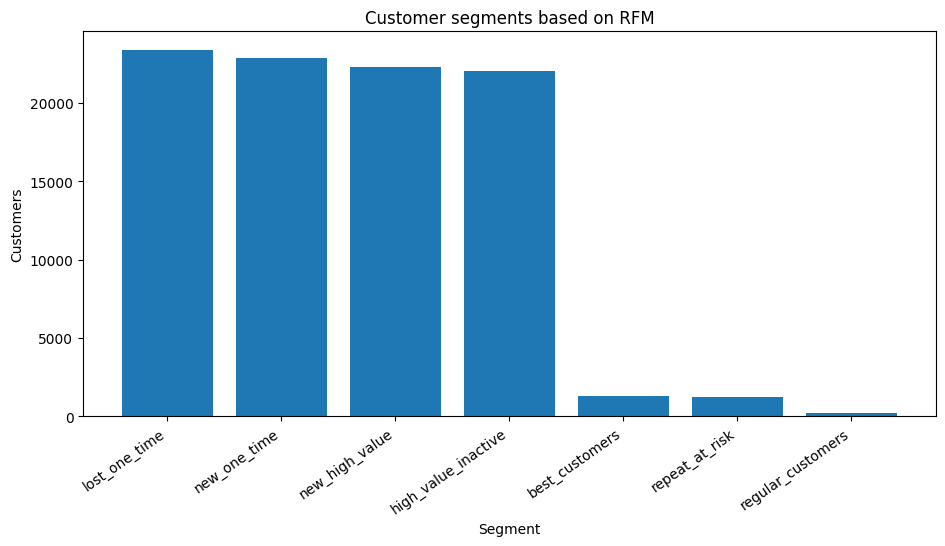

In [182]:
plt.figure(figsize=(11, 5))

plt.bar(segment_counts["segment"], segment_counts["customers"])

plt.title("Customer segments based on RFM")
plt.xlabel("Segment")
plt.ylabel("Customers")
plt.xticks(rotation=35, ha="right")
plt.show()


In [183]:
rfm_summary = (
    rfm.groupby("segment")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        repeat_share=("frequency_segment", lambda x: (x == "repeat").mean())
    )
    .round(2)
    .sort_values("customers", ascending=False)
)

rfm_summary


,customers,avg_recency,avg_frequency,avg_monetary,repeat_share
segment,,,,,
lost_one_time,23379,413.28,1.00,47.23,0.0
new_one_time,22842,160.63,1.00,47.01,0.0
new_high_value,22294,161.19,1.00,231.78,0.0
high_value_inactive,22042,413.95,1.00,233.55,0.0
best_customers,1310,162.00,2.16,300.28,1.0
repeat_at_risk,1258,401.60,2.08,254.82,1.0
regular_customers,233,160.04,2.03,62.17,1.0


### Промежуточный вывод: RFM-сегментация

Из-за низкой доли повторных покупок большинство клиентов попадает в one-time сегменты. Это согласуется с результатами когортного анализа и repeat purchase rate: продукту важно работать не только над привлечением новых покупателей, но и над возвратом клиентов после первой покупки.

Наиболее интересные группы для продуктовых действий:
- `best_customers` — повторные и ценные клиенты, для них стоит поддерживать лояльность;
- `new_high_value` — недавние клиенты с высоким чеком, перспективны для повторных коммуникаций;
- `high_value_inactive` — клиенты с высоким monetary, которые давно не покупали; подходят для реактивации;
- `lost_one_time` — большая группа разовых неактивных покупателей, для неё нужны более дешёвые и массовые retention-механики.


## 14. Автоматический итог по ключевым метрикам


In [184]:
gmv = business_metrics.loc[0, "gmv"]
freight_value = business_metrics.loc[0, "freight_value"]
total_customer_paid = business_metrics.loc[0, "total_customer_paid"]
delivered_orders = business_metrics.loc[0, "delivered_orders"]
unique_customers = business_metrics.loc[0, "unique_customers"]
avg_order_value_with_freight = aov.loc[0, "avg_order_value_with_freight"]
repeat_rate = repeat_purchase.loc[0, "repeat_purchase_rate"]
late_rate = delivery_metrics.loc[0, "late_delivery_rate"]

estimated_revenue_10 = gmv * 0.10
estimated_revenue_20 = gmv * 0.20

print("SUMMARY")
print("-" * 40)
print(f"GMV: {gmv:,.2f}")
print(f"Freight value: {freight_value:,.2f}")
print(f"Total customer paid: {total_customer_paid:,.2f}")
print(f"Estimated platform revenue range, 10-20% commission: {estimated_revenue_10:,.2f} - {estimated_revenue_20:,.2f}")
print(f"Delivered orders: {delivered_orders:,}")
print(f"Unique customers: {unique_customers:,}")
print(f"Average order value with freight: {avg_order_value_with_freight:,.2f}")
print(f"Repeat purchase rate: {repeat_rate:.2%}")
print(f"Late delivery rate: {late_rate:.2%}")
print(f"Top category by GMV: {top_categories.loc[0, 'category']}")


SUMMARY
----------------------------------------
GMV: 13,221,498.11
Freight value: 2,198,275.64
Total customer paid: 15,419,773.75
Estimated platform revenue range, 10-20% commission: 1,322,149.81 - 2,644,299.62
Delivered orders: 96,478
Unique customers: 93,358
Average order value with freight: 159.83
Repeat purchase rate: 3.00%
Late delivery rate: 6.77%
Top category by GMV: health_beauty


### Краткий итог по числам

Ключевые метрики проекта:
- GMV: около 13.2 млн;
- freight value: около 2.2 млн;
- total customer paid: около 15.4 млн;
- estimated platform revenue при комиссии 10–20%: примерно 1.3–2.6 млн;
- доставленные заказы: 96 478;
- уникальные клиенты с доставленными заказами: 93 358;
- средний чек с доставкой: около 160;
- repeat purchase rate: около 3%;
- late delivery rate: около 6.8%;
- крупнейшая категория по GMV: `health_beauty`.


## 15. Итоговые выводы и продуктовые рекомендации

### Основные выводы
1. **GMV и заказы концентрируются в ключевых категориях.**  
   Наибольший вклад в GMV дают категории `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure` и `computers_accessories`. Эти категории стоит рассматривать как приоритетные для контроля качества, маркетинга и рекомендаций.

2. **Повторные покупки — слабое место продукта.**  
   Repeat purchase rate составляет около 3%, а когортный retention после первой покупки обычно ниже 1%. Это говорит о большой доле разовых покупателей и показывает потенциал роста через удержание.

3. **Доставка существенно влияет на пользовательский опыт.**  
   В среднем заказы доставляются раньше обещанной даты, но около 6.8% доставленных заказов имеют задержку. При увеличении задержки средняя оценка пользователя резко падает: от примерно 4.29 для заказов без задержки до примерно 1.70 для задержек больше 8 дней.

4. **Есть региональные различия в качестве доставки.**  
   По отдельным регионам late delivery rate заметно выше среднего. Это значит, что проблему доставки нужно анализировать не только на общем уровне, но и в разрезе регионов, продавцов и логистических направлений.

5. **RFM-сегментация подтверждает проблему удержания.**  
   Большая часть клиентов относится к one-time сегментам. Поэтому для роста продукта важно отдельно работать с новыми клиентами, high-value inactive клиентами и repeat-покупателями с риском ухода.

### Рекомендации

1. **Развивать повторные покупки.**  
   Запустить механики удержания: персональные рекомендации, скидки на повторный заказ, email/push-коммуникации после первой покупки.

2. **Сфокусироваться на high-value клиентах.**  
   Для клиентов с высоким monetary, но низкой недавней активностью можно запускать reactivation-кампании.

3. **Улучшать доставку как guardrail-метрику.**  
   Late delivery rate нужно отслеживать по регионам и продавцам, потому что задержки сильно снижают оценки пользователей.

4. **Использовать ключевые категории для роста.**  
   Категории с максимальным GMV можно использовать для рекомендаций, промо и контроля качества продавцов.

### Итог

Главный продуктовый инсайт: Olist имеет значительный товарный оборот и сильные категории, но основная зона роста — удержание клиентов и повторные покупки. При этом доставка является критичной guardrail-метрикой: задержки заметно ухудшают пользовательский опыт и могут снижать вероятность повторного заказа.
